In [9]:
print("Final Project Step 2 - Tej Shah")

Final Project Step 2 - Tej Shah


In [8]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
file_path = "/Users/Tej/Documents/GitHub/BIOS-584/data/Full_F1_Dataset.xlsx"
quali = pd.read_excel(file_path, sheet_name="qualifying")
lap_time = pd.read_excel(file_path, sheet_name="lap_times")
race_result = pd.read_excel(file_path, sheet_name="results")
drivers = pd.read_excel(file_path, sheet_name="drivers")
ham_id = 1
driver_ids = {
    "Hamilton": 1,
    "Alonso": 4,
    "Vettel": 20,
    "Schumacher": 30,
    "Raikkonen": 8
}

In [3]:
print("Objective 2: Summary Statistics of Variables")

# 1. Hamilton qualifying position
ham_quali = quali[quali["driverId"] == ham_id]["position"]
quali_stats = {
    "Variable": "Qualifying Position",
    "Min": ham_quali.min(),
    "Max": ham_quali.max(),
    "Mean": ham_quali.mean(),
    "Std Dev": ham_quali.std(),
    "IQR": ham_quali.quantile(0.75) - ham_quali.quantile(0.25)
}

# 2. Hamilton race finishing position
ham_race = race_result[race_result["driverId"] == ham_id]["positionOrder"]
race_stats = {
    "Variable": "Race Finishing Position",
    "Min": ham_race.min(),
    "Max": ham_race.max(),
    "Mean": ham_race.mean(),
    "Std Dev": ham_race.std(),
    "IQR": ham_race.quantile(0.75) - ham_race.quantile(0.25)
}

# 3. Hamilton lap time per race
ham_laps = lap_time[lap_time["driverId"] == ham_id]
ham_avg_lap = ham_laps.groupby("raceId")["milliseconds"].mean()
lap_stats = {
    "Variable": "Average Lap Time (ms)",
    "Min": ham_avg_lap.min(),
    "Max": ham_avg_lap.max(),
    "Mean": ham_avg_lap.mean(),
    "Std Dev": ham_avg_lap.std(),
    "IQR": ham_avg_lap.quantile(0.75) - ham_avg_lap.quantile(0.25)
}

summary_table = pd.DataFrame([quali_stats, race_stats, lap_stats])
summary_table


Objective 2: Summary Statistics of Variables


,Variable,Min,Max,Mean,Std Dev,IQR
0,Qualifying Position,1.000000,22.0,4.073034,4.232038,4.000000
1,Race Finishing Position,1.000000,24.0,5.019663,5.551009,5.000000
2,Average Lap Time (ms),69238.774648,209672.0,98748.650303,18498.167215,21359.364791


Objective 3: SAP

To address the first aim, which will evaluate whether Lewis Hamilton consistently outperforms other drivers in qualifying sessions, I will need to compare consistency and the mean qualifying positions. Since the qualifying position variable is continuous, I will get the mean qualifying position of all drivers and conduct a multiple linear regression test to compare the mean qualifying position of Hamilton compared to other drivers. A linear regression will give me effect sizes and p-values, which will allow me to evaluate the qualifying performance of Hamilton. I will also take the top 5 drivers, excluding Hamilton, from these regression analyses and create side-by-side density box plots so I can also visually see the difference and compare consistency by looking at the variance and spread. Finally, I will look at the standard deviation in qualifying position between these 6 drivers to confirm the consistency of qualifying performance.

For the second aim, which will examine whether Hamilton is more consistent in race finishing position compared to other top drivers, I will do a similar analysis to the first aim. However, in addition to a linear regression for mean race position and a consistency analysis using standard deviation and boxplot comparison of the top 5 drivers and Hamilton, I can take the analysis a step further. For the race finish position, I can also look at whether there is a greater dependency of finishing position on the starting position for Hamilton compared to the other drivers. To do this, I can first do a linear regression between finishing and starting position (both are continuous) for the top 6 drivers and then compare the regression slope using Pearson's correlational analysis, where the "r" will tell how dependent the finishing position is on starting position for each driver.  

For the third aim, which will investigate whether Hamilton maintains a faster race pace than other drivers under similar race conditions, I will compute the average lap time per race for each driver and compare it with Hamilton. Again, this analysis will be similar to the first and second aims. However, I need to consider potential confounders for this question, and I will exclude laptimes for drivers with less than max laps - 5 completed. For instance, if someone only completes 10/50 laps for a race, their laptimes will be excluded. Doing this, the linear regression will be more accurate. As for the previous two aims, I will follow the linear regression with a comparison using boxplots and standard deviation to confirm consistency.

All statistical analyses will be conducted using Python 3.

Objective 4: Graphs to get insight

Three different side-by-side density boxplots of qualifying positions, race finish positions, and laptimes during the race for the top 5 drivers with the lowest mean, plus Hamilton, would give me great insight into the research questions, as I will be able to visually assess and compare Hamilton to other drivers in order to answer my hypothesis of whether Hamilton is the best F1 driver. Through these boxplots,  I can see who qualifies better and who is more consistent by looking at the height, spread, and the number of data points for each driver. 

Another type of graph I can use to get more insight into the second question is a faceted scatterplot of starting grid position versus finishing position. This will show whether Hamilton finishes above expectation based on his starting grid position and whether his performance is less dependent on starting order.

In [45]:
print("Final Project Step 3 - Tej Shah") 

Final Project Step 3 - Tej Shah


Data Analysis: Addendum to SAP - Instead of the top 5 drivers except Hamilton, I will compare Lewis Hamilton with other top 4 drivers in a similar era, all of whom have a high number of races, multiple championships, and reputation as being top drivers. This is because there are 100s of drivers in the dataset and most have very few races (less than 50 compared to Hamilton who has over 300) and have competed in a different era where the car technology, regulations and rules were vastly different. I have chosen Vettel, Raikkonen, Schumacher and Alonso as the drivers to compare as they raced during a similar time and had a similar amount of races completed, making the comparison fair and less biased.

Aim 1: Qualifying summary (mean, SD, n)
       Driver  mean_position  sd_position  n_races
0    Hamilton       4.073034     4.232038      356
1      Alonso       8.139535     4.760716      387
2      Vettel       6.247492     5.500972      299
3  Schumacher       5.666667     4.701936      192
4   Raikkonen       7.654206     5.299946      321

Aim 1: Linear regression of qualifying position on driver
                            OLS Regression Results                            
Dep. Variable:               position   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     38.52
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           8.98e-31
Time:                        15:49:41   Log-Likelihood:                -4677.7
No. Observations:                1555   AIC:                             9365.
Df Residuals:                    1550   BI

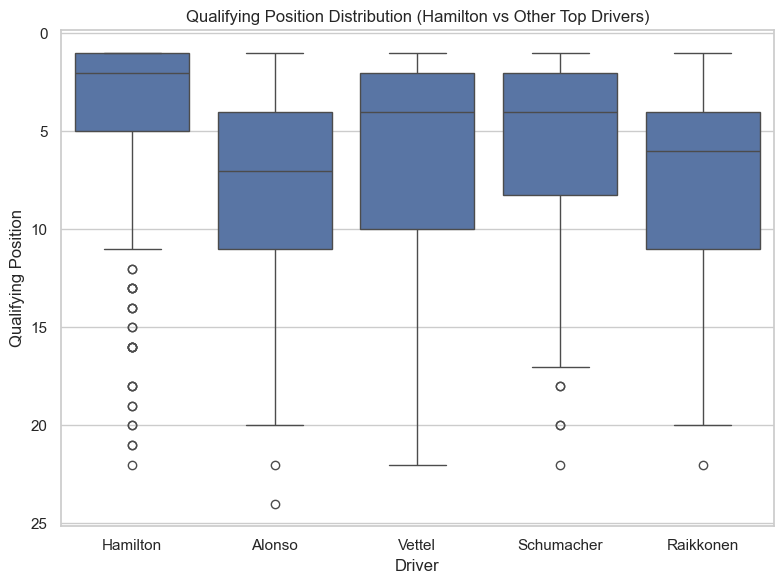

In [71]:
sns.set(style="whitegrid")
target_ids = list(driver_ids.values())
quali_5 = quali[quali["driverId"].isin(target_ids)].copy()

id_to_name = {v: k for k, v in driver_ids.items()} #This is for Raikkonen, his Finnish last name will have symbols otherwise
quali_5["Driver"] = quali_5["driverId"].map(id_to_name)

driver_order = ["Hamilton", "Alonso", "Vettel", "Schumacher", "Raikkonen"]
quali_5["Driver"] = pd.Categorical(quali_5["Driver"], categories=driver_order)

#Descriptive stats
qual_summary = (
    quali_5.groupby("Driver", observed=False)["position"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "mean_position", "std": "sd_position", "count": "n_races"})
)

print("Aim 1: Qualifying summary (mean, SD, n)")
print(qual_summary)

#Linear Regression
model_quali = smf.ols("position ~ C(Driver)", data=quali_5).fit()

print("\nAim 1: Linear regression of qualifying position on driver")
print(model_quali.summary())

#Boxplot to visualize
plt.figure(figsize=(8, 6))
sns.boxplot(data=quali_5, x="Driver", y="position", order=driver_order)
plt.gca().invert_yaxis()  # P1 at the top
plt.xlabel("Driver")
plt.ylabel("Qualifying Position")
plt.title("Qualifying Position Distribution (Hamilton vs Other Top Drivers)")
plt.tight_layout()
plt.show()


Schumacher has a lower n_races here because qualifying rules were changed after he already completed 100+ races, thus his old races under older qualifying rules were excluded. 


AIM 2: Summary statistics
            mean_finish  sd_finish  n_races  median_finish   IQR
Driver                                                          
Hamilton       5.019663   5.551009      356            3.0   5.0
Alonso         8.492574   6.043469      404            7.0  10.0
Vettel         7.093333   6.405836      300            4.0   9.0
Schumacher     6.879870   7.072577      308            3.0  10.0
Raikkonen      8.491477   6.170413      352            7.0  10.0

AIM 2: Regression of finishing position on driver
                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     19.21
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.79e-15
Time:                        15:55:07   Log-Likelihood:                -

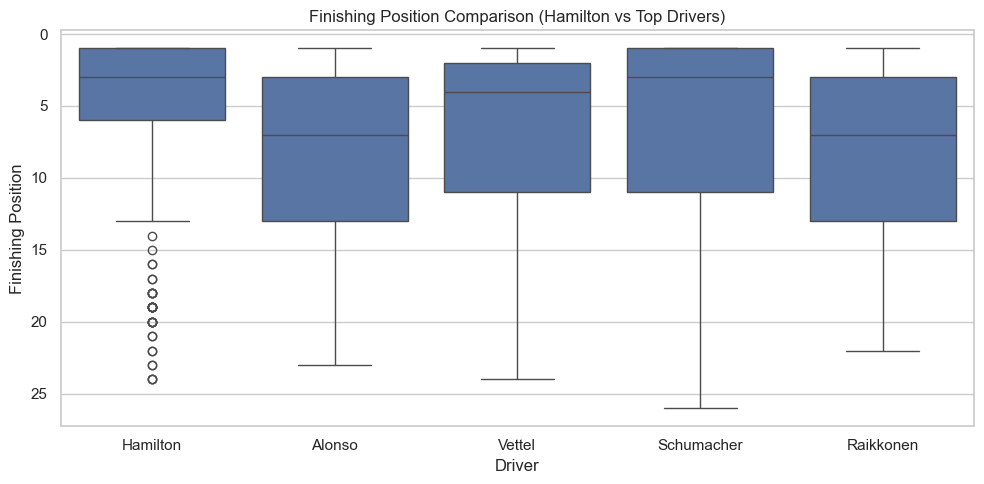

In [74]:
sns.set(style="whitegrid")

selected = list(driver_ids.values())
race_5 = race_result[race_result["driverId"].isin(selected)].copy()
race_5["Driver"] = race_5["driverId"].map(id_to_name)

driver_order = ["Hamilton", "Alonso", "Vettel", "Schumacher", "Raikkonen"]
race_5["Driver"] = pd.Categorical(race_5["Driver"], categories=driver_order)

#Droping missing starting or finishing position
race_5 = race_5.dropna(subset=["grid", "positionOrder"])

#Summary Statistics
race_summary = (
    race_5.groupby("Driver", observed=False)["positionOrder"]
    .agg(["mean", "std", "count", "median",
          lambda x: x.quantile(0.75) - x.quantile(0.25)])
)

race_summary.columns = ["mean_finish", "sd_finish", "n_races", "median_finish", "IQR"]
print("\nAIM 2: Summary statistics")
print(race_summary)

#Linear Regression
model_finish = smf.ols("positionOrder ~ C(Driver)", data=race_5).fit()
print("\nAIM 2: Regression of finishing position on driver")
print(model_finish.summary())

slopes = {}
correlations = {}

for d in selected:
    temp = race_5[race_5["driverId"] == d]
    name = temp["Driver"].iloc[0]

    # regression slope
    m = smf.ols("positionOrder ~ grid", data=temp).fit()
    slopes[name] = m.params["grid"]

    # correlation
    r, p = pearsonr(temp["grid"], temp["positionOrder"])
    correlations[name] = (r, p)

print("\nPearson correlations ")
for name, (r, p) in correlations.items():
    print(f"{name}: r={r:.3f}, p={p:}")

#Boxplot to Visualize
plt.figure(figsize=(10, 5))
sns.boxplot(data=race_5, x="Driver", y="positionOrder", order=driver_order)
plt.gca().invert_yaxis()
plt.title("Finishing Position Comparison (Hamilton vs Top Drivers)")
plt.xlabel("Driver")
plt.ylabel("Finishing Position")
plt.tight_layout()
plt.show()



AIM 3: Lap time summary (ms)
                 mean_ms         sd_ms  n_races           IQR
Driver                                                       
Hamilton    95485.220833  37952.332909      328  19364.150000
Alonso      95327.144545  37634.431908      330  18077.516667
Vettel      95377.759259  28307.476452      261  19941.333333
Schumacher  90379.881779  12502.028297      193  17743.500000
Raikkonen   93085.599825  27818.084013      285  19335.833333

AIM 3: Regression of race pace on driver
                            OLS Regression Results                            
Dep. Variable:             avg_lap_ms   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.121
Date:                Fri, 05 Dec 2025   Prob (F-statistic):              0.345
Time:                        16:09:25   Log-Likelihood:                -16457.
No. Observations:   

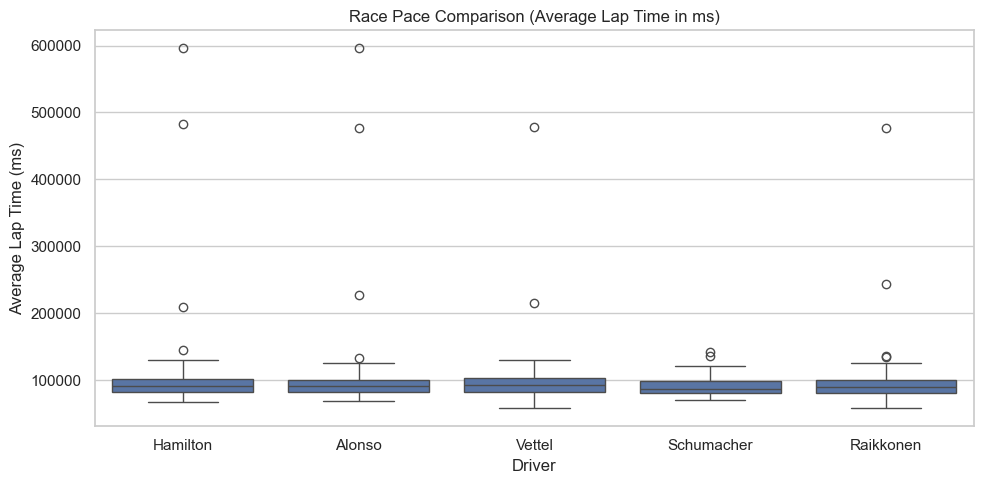

In [79]:
selected = list(driver_ids.values())

# Cleaning up data
race_max_laps = lap_time.groupby("raceId")["lap"].max().reset_index()
race_max_laps.rename(columns={"lap": "max_laps"}, inplace=True)

lap = lap_time.merge(race_max_laps, on="raceId", how="left")

lap["valid"] = lap["lap"] >= (lap["max_laps"] - 5)
lap_valid = lap[lap["valid"]] #only those who completed most laps

avg_laptimes = lap_valid.groupby(["raceId", "driverId"])["milliseconds"].mean().reset_index()
avg_laptimes.rename(columns={"milliseconds": "avg_lap_ms"}, inplace=True)
avg_laptimes = avg_laptimes[avg_laptimes["driverId"].isin(selected)]
avg_laptimes["Driver"] = avg_laptimes["driverId"].map(id_to_name) #getting average laps

driver_order = ["Hamilton", "Alonso", "Vettel", "Schumacher", "Raikkonen"]
avg_laptimes["Driver"] = pd.Categorical(avg_laptimes["Driver"], categories=driver_order)

#Summary Stastistics
pace_summary = (
    avg_laptimes.groupby("Driver", observed = False)["avg_lap_ms"]
    .agg(["mean", "std", "count",
          lambda x: x.quantile(0.75) - x.quantile(0.25)])
)

pace_summary.columns = ["mean_ms", "sd_ms", "n_races", "IQR"]
print("\nAIM 3: Lap time summary (ms)")
print(pace_summary)

#Linear Regression
model_pace = smf.ols("avg_lap_ms ~ C(Driver)", data=avg_laptimes).fit()
print("\nAIM 3: Regression of race pace on driver")
print(model_pace.summary())

#Boxplot for Visualization
plt.figure(figsize=(10,5))
sns.boxplot(data=avg_laptimes, x="Driver", y="avg_lap_ms", order=driver_order)
plt.title("Race Pace Comparison (Average Lap Time in ms)")
plt.xlabel("Driver")
plt.ylabel("Average Lap Time (ms)")
plt.tight_layout()
plt.show()


Graphs to Visualize comparisons better

In [82]:
drivers_short = drivers[["driverId", "surname"]].rename(columns={"surname": "Driver"})
drivers_short["Driver"] = drivers_short["Driver"].replace(
    {"R√§ikk√∂nen": "Raikkonen", "Raikkonen": "Raikkonen"}
)

quali_top = quali[quali["driverId"].isin(target_ids)].merge(
    drivers_short, on="driverId", how="left"
)

race_top = race_result[race_result["driverId"].isin(target_ids)].merge(
    drivers_short, on="driverId", how="left"
)

avg_laps = (
    lap_time.groupby(["raceId", "driverId"])["milliseconds"]
    .mean()
    .reset_index(name="avg_lap")
)

pace_top = avg_laps[avg_laps["driverId"].isin(target_ids)].merge(
    drivers_short, on="driverId", how="left"
)

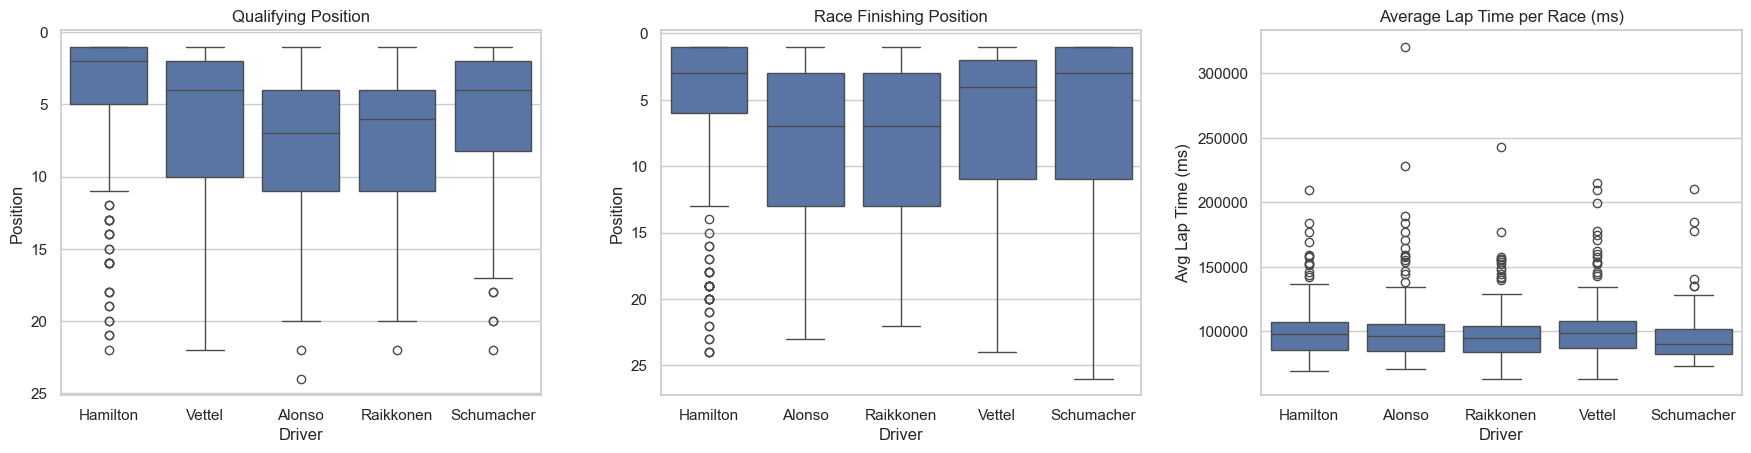

In [83]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))

sns.boxplot(data=quali_top, x="Driver", y="position", ax=axes[0])
axes[0].set_title("Qualifying Position")
axes[0].set_ylabel("Position")
axes[0].invert_yaxis()  

sns.boxplot(data=race_top, x="Driver", y="positionOrder", ax=axes[1])
axes[1].set_title("Race Finishing Position")
axes[1].set_ylabel("Position")
axes[1].invert_yaxis()

sns.boxplot(data=pace_top, x="Driver", y="avg_lap", ax=axes[2])
axes[2].set_title("Average Lap Time per Race (ms)")
axes[2].set_ylabel("Avg Lap Time (ms)")

plt.tight_layout(pad=2)
plt.show()

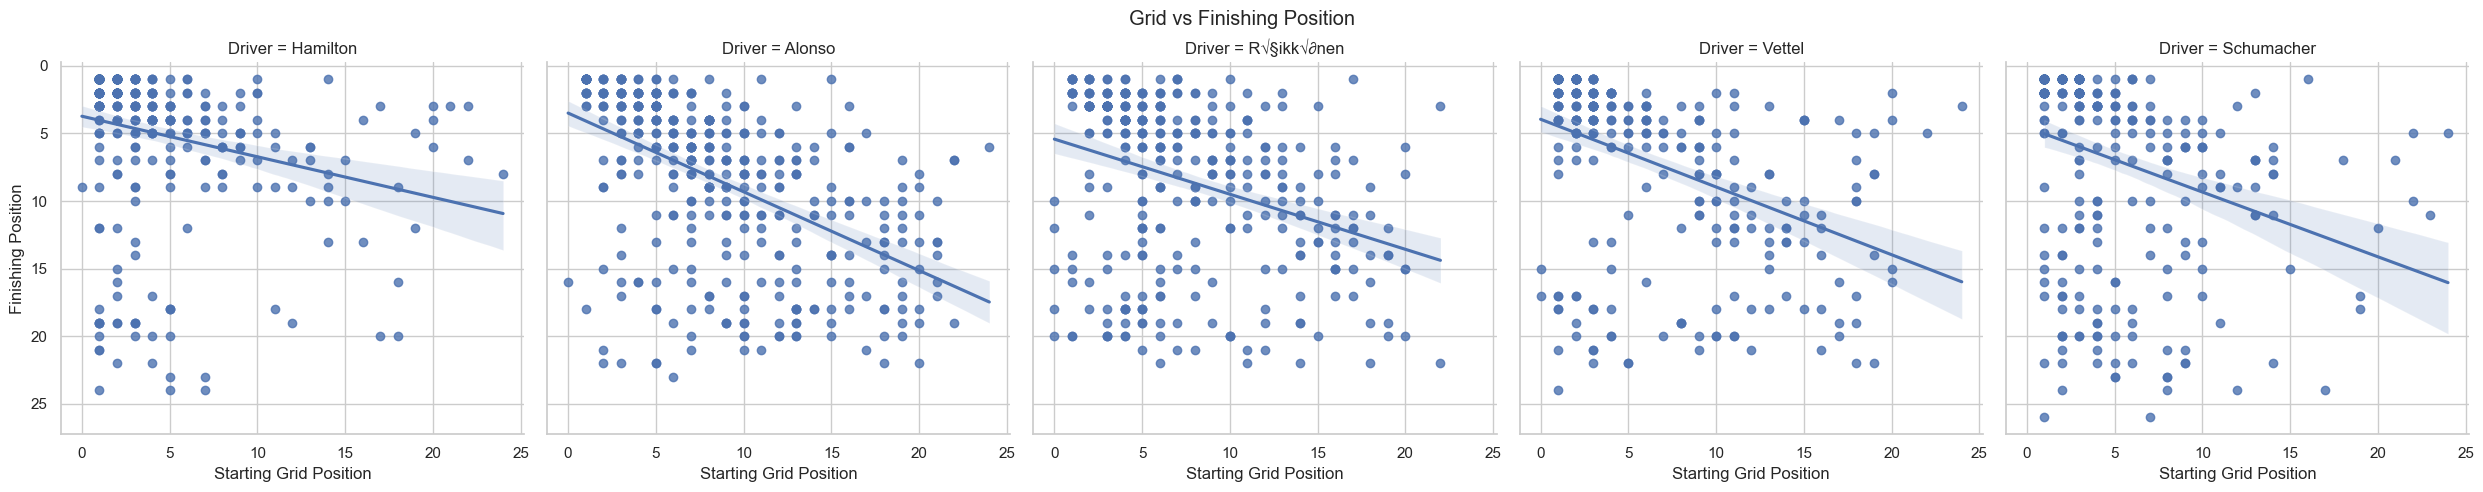

In [77]:
g = sns.lmplot(
    data=race_top,
    x="grid",
    y="positionOrder",
    col="Driver"
)

for ax in g.axes.flatten():
    ax.invert_yaxis()
    ax.set_xlabel("Starting Grid Position")
    ax.set_ylabel("Finishing Position")
    
g.fig.subplots_adjust(top=0.875)
g.fig.suptitle("Grid vs Finishing Position")

plt.show()